# Step 90 RMS versus cell number

<>:113: SyntaxWarning: invalid escape sequence '\p'
<>:113: SyntaxWarning: invalid escape sequence '\p'
/var/folders/r6/5h5k9z756f50_klfmvf_7cp40000gn/T/ipykernel_17314/2810751889.py:113: SyntaxWarning: invalid escape sequence '\p'
  linewidth=2.5, label=f'Mean $\pm$ 1 STD')


Extracting data for Unweighted Periodic...
Extracting data for Weighted Periodic...
Extracting data for Unweighted Finite...
Extracting data for Weighted Finite...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Grid plot successfully generated and saved!


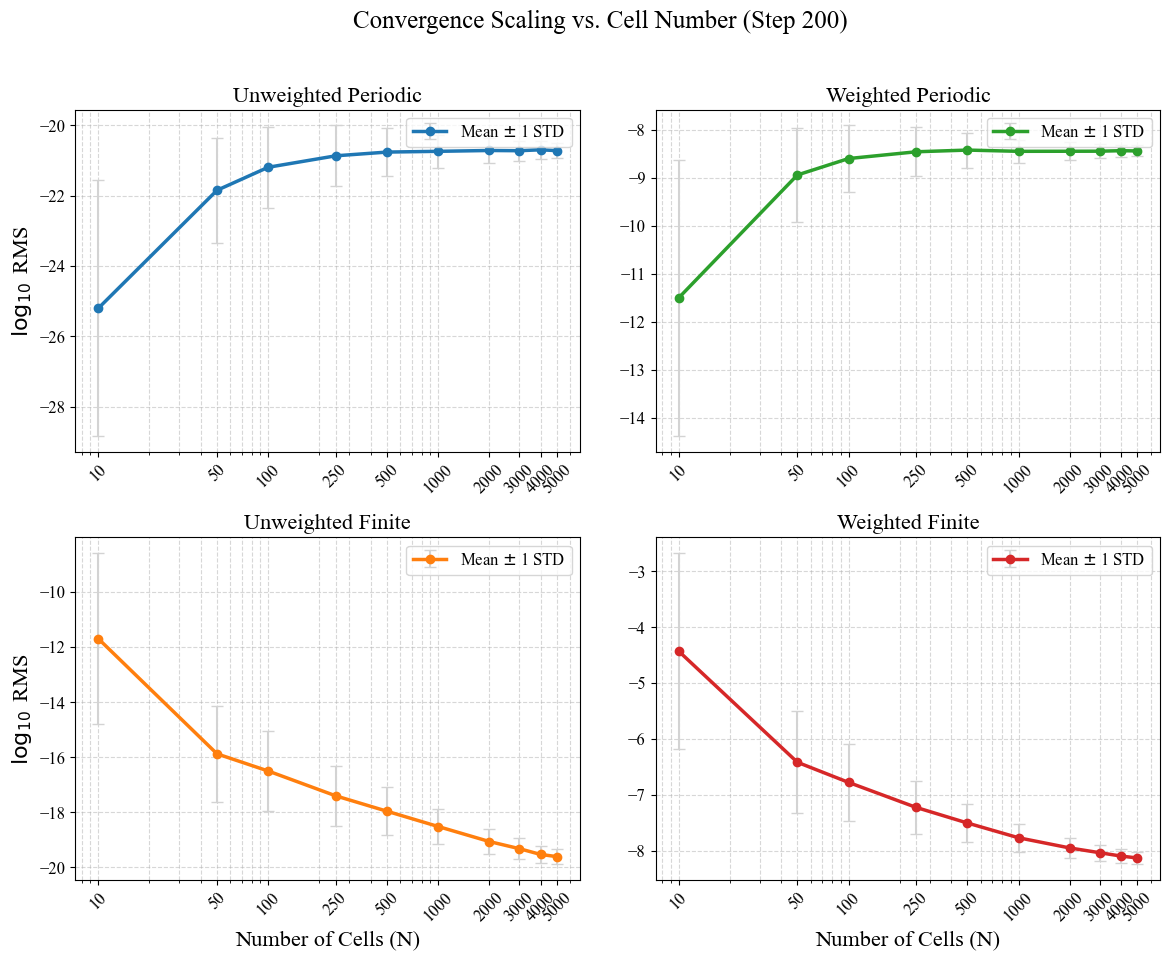

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ==========================================
# 1) Setup & Publication styling
# ==========================================
# Match academic journal font settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18
})

N_values = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000]

# Target step: 200th step (index 199)
target_step = 199 

# Map the 4 folders to their grid positions: (row, col)
# Rows: 0=Periodic, 1=Finite
# Cols: 0=Unweighted, 1=Weighted
configs = [
    {
        "folder": "a_unweighted_periodic", 
        "title": "Unweighted Periodic", 
        "pos": (0, 0), 
        "color": "tab:blue"
    },
    {
        "folder": "c_weighted_periodic", 
        "title": "Weighted Periodic", 
        "pos": (0, 1), 
        "color": "tab:green"
    },
    {
        "folder": "b_unweighted_finite", 
        "title": "Unweighted Finite", 
        "pos": (1, 0), 
        "color": "tab:orange"
    },
    {
        "folder": "d_weighted_finite", 
        "title": "Weighted Finite", 
        "pos": (1, 1), 
        "color": "tab:red"
    }
]

# ==========================================
# 2) Figure Setup
# ==========================================
fig, axes = plt.subplots(
    nrows=2, 
    ncols=2, 
    figsize=(14, 10), 
    gridspec_kw={'wspace': 0.15, 'hspace': 0.25}
)

# ==========================================
# 3) Data Extraction & Plotting Loop
# ==========================================
for config in configs:
    row_idx, col_idx = config["pos"]
    ax = axes[row_idx, col_idx]
    
    folder = config["folder"]
    color = config["color"]
    title = config["title"]
    
    means = []
    stds = []
    valid_N = []
    
    print(f"Extracting data for {title}...")
    
    for N in N_values:
        path_primary = os.path.join(folder, f"cell_data_{N}", 'log_rms_vs_steps.npy')
        path_fallback = os.path.join(folder, str(N), 'log_rms_vs_steps.npy')
        
        file_path = None
        if os.path.exists(path_primary):
            file_path = path_primary
        elif os.path.exists(path_fallback):
            file_path = path_fallback
            
        if file_path:
            data = np.load(file_path)
            
            # Safely get the target step (or the last available step if array is shorter)
            idx = target_step if data.shape[1] > target_step else -1
            
            means.append(data[0, idx])
            stds.append(data[1, idx])
            valid_N.append(N)
        else:
            pass # Silent skip if N folder isn't found
            
    # Plot if data exists
    if valid_N:
        means = np.array(means)
        stds = np.array(stds)

        ax.errorbar(valid_N, means, yerr=stds, fmt='-o', color=color, 
                     ecolor='lightgray', elinewidth=1.5, capsize=4, markersize=6,
                     linewidth=2.5, label=f'Mean $\pm$ 1 STD')

    # Formatting for this specific subplot
    ax.set_title(title)
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xticks(N_values)
    ax.set_xticklabels([str(n) for n in N_values], rotation=45)
    
    # Only show Y-label on the left column to keep it clean
    if col_idx == 0:
        ax.set_ylabel(r"$\log_{10}$ RMS")
        
    # Only show X-label on the bottom row
    if row_idx == 1:
        ax.set_xlabel("Number of Cells (N)")
        
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(loc='upper right')

# ==========================================
# 4) Export and Show
# ==========================================
fig.suptitle(f"Convergence Scaling vs. Cell Number (Step {target_step + 1})", y=0.98)

plt.savefig('All_Algorithms_Scaling_Step200_2x2.png', dpi=300, bbox_inches='tight')
plt.savefig('All_Algorithms_Scaling_Step200_2x2.eps', format='eps', bbox_inches='tight')

print("\nGrid plot successfully generated and saved!")
plt.show()